In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/raw/amazon_ecommerce_1M.csv')

Recreating enginneered features

In [4]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

In [5]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

In [6]:
df['return_flag'] = df['is_returned'].astype(int)

In [7]:
df['delay_flag'] = np.where(
    df['delivery_status'] == 'Delayed',
    1,
    0
)

In [8]:
df['inventory_risk'] = np.where(
    df['stock'] < 50,
    'High Risk',
    'Low Risk'
)

In [14]:
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status,return_flag,delay_flag,inventory_risk,fulfilled_flag
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned,1,0,Low Risk,0
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned,1,0,Low Risk,0
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned,1,0,Low Risk,0
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit,0,0,Low Risk,1
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed,0,1,Low Risk,0


# Supply Chain KPI Analysis

in this section I evaluate operational performance using key logistics and inventory management metrics.

## KPI 1- Fill Rate
- Measuring how sucessfully customer demand is fulfilled

We define:
- delivered/in transit = fulfilled
- returned/delayed = not perfectly fulfilled

In [9]:
df['fulfilled_flag'] = np.where(
    df['delivery_status'].isin(['Delivered', 'In Transit']),
    1,
    0
)

In [12]:
df['fulfilled_flag'].sum()

np.int64(589027)

In [10]:
fill_rate = (
    df['fulfilled_flag'].sum() / len(df)
) * 100

print(f"Fill Rate: {fill_rate:.2f}%")

Fill Rate: 58.90%


## Business Interpretation

A 58.90% fill rate indicates a stable operational performance and inventory availability which still needs improvement

Improving fill rate helps:
- customer satisfaction
- revenue retention
- operational reliability

## KPI 2- Return Rate

In [13]:
return_rate = (
    df['return_flag'].sum() / len(df)
) * 100

print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 11.60%


Return Rate by Category

In [15]:
category_returns = (
    df.groupby('category')['return_flag']
    .mean()
    * 100
).sort_values(ascending=False)

category_returns

category
Beauty         11.756059
Clothing       11.736328
Sports         11.645964
Home           11.584097
Electronics    11.273358
Name: return_flag, dtype: float64

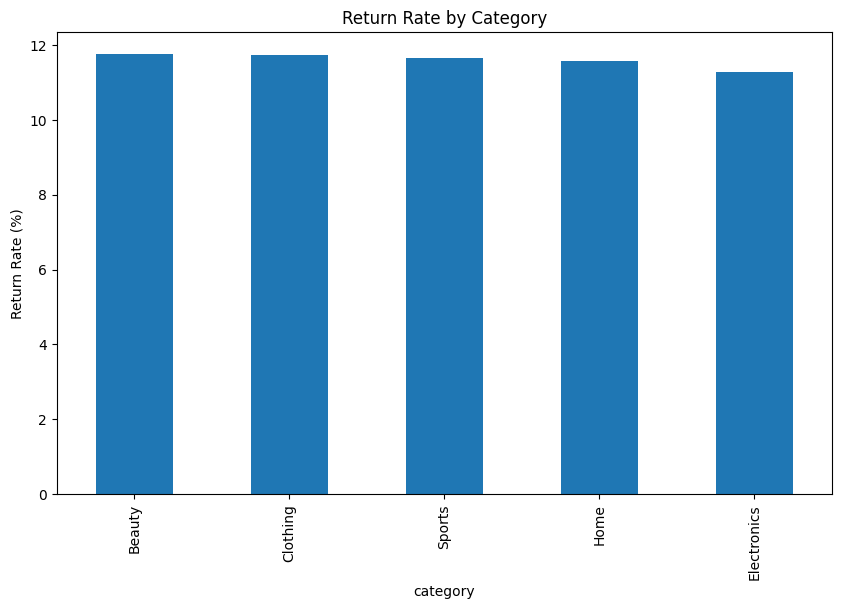

In [16]:
plt.figure(figsize=(10,6))

ax = category_returns.plot(kind='bar')

plt.title('Return Rate by Category')
plt.ylabel('Return Rate (%)')

plt.show()

## KPI 3- Average Shipping Time

In [17]:
avg_shipping_time = df['shipping_time_days'].mean()

print(f"Average Shipping Time: {avg_shipping_time:.2f} Days")

Average Shipping Time: 3.17 Days


Shipping By Category

In [18]:
shipping_by_category = (
    df.groupby('category')['shipping_time_days']
    .mean()
    .sort_values()
)

shipping_by_category

category
Clothing       3.161943
Electronics    3.164849
Beauty         3.167800
Sports         3.167973
Home           3.169369
Name: shipping_time_days, dtype: float64

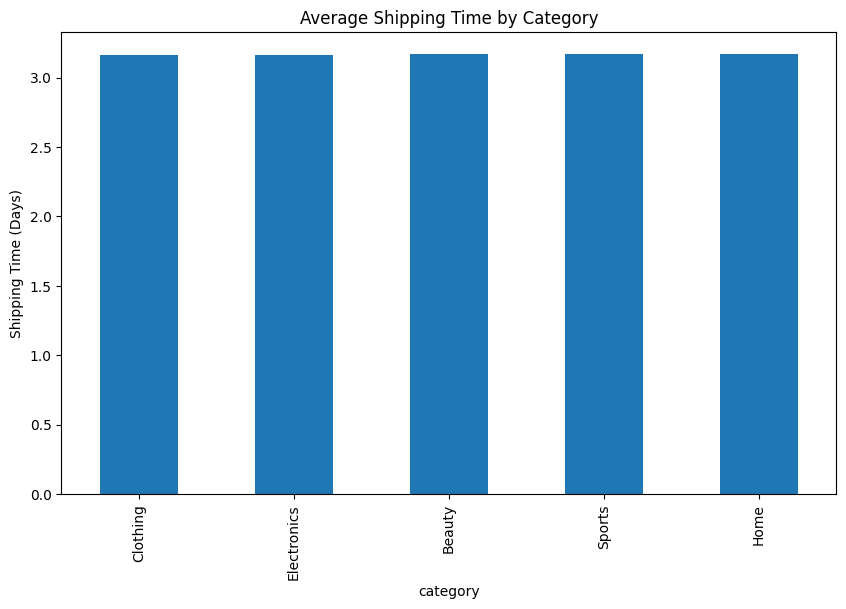

In [19]:
plt.figure(figsize=(10,6))

shipping_by_category.plot(kind='bar')

plt.title('Average Shipping Time by Category')
plt.ylabel('Shipping Time (Days)')

plt.show()

## KPI 4- Delayed Shipment Rate

In [39]:
delay_rate = (
    df['delay_flag'].sum() / len(df)
) * 100

print(f"Delayed Shipment Rate: {delay_rate:.2f}%")

Delayed Shipment Rate: 29.50%


Delay Rate by Location

In [21]:
location_delay = (
    df.groupby('location')['delay_flag']
    .mean()
    * 100
).sort_values(ascending=False)

location_delay

location
Delhi        29.822725
Mumbai       29.795771
Bangalore    29.373845
Chennai      29.267341
Hyderabad    29.230075
Name: delay_flag, dtype: float64

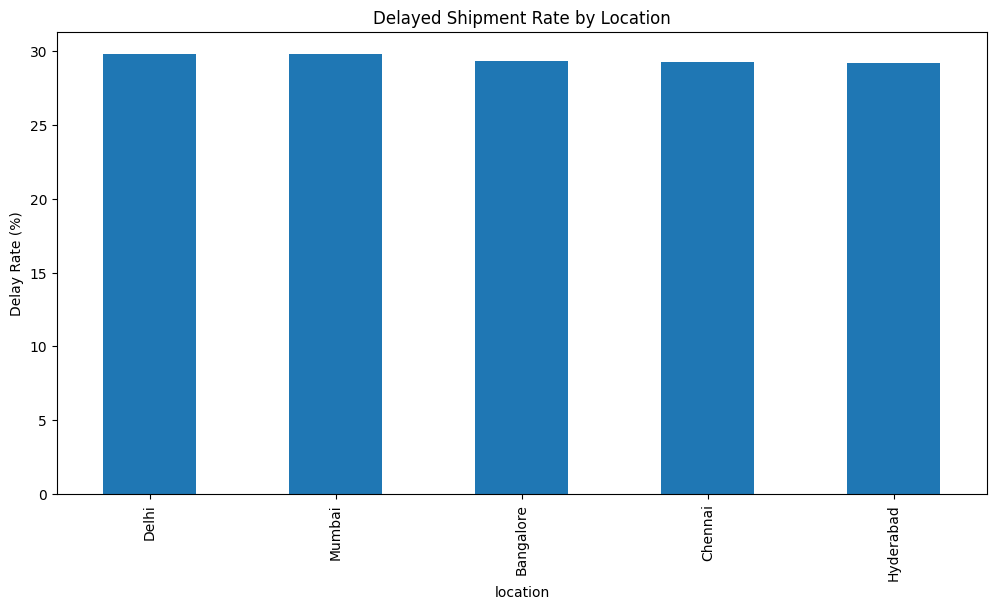

In [22]:
plt.figure(figsize=(12,6))

location_delay.plot(kind='bar')

plt.title('Delayed Shipment Rate by Location')
plt.ylabel('Delay Rate (%)')

plt.show()

## KPI 5- Inventory Risk Analysis

Inventory Risk distribution

In [23]:
inventory_risk_counts = (
    df['inventory_risk']
    .value_counts()
)

inventory_risk_counts

inventory_risk
Low Risk     900311
High Risk     99689
Name: count, dtype: int64

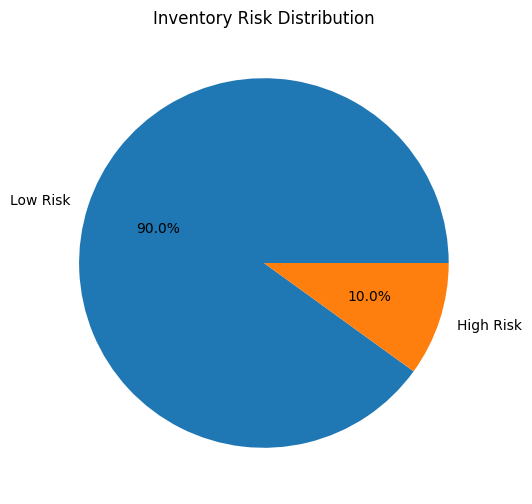

In [24]:
plt.figure(figsize=(6,6))

inventory_risk_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Inventory Risk Distribution')
plt.ylabel('')

plt.show()

## Business Interpretation

Products classified as high inventory risk may face potential stockouts due to low available inventory.

Monitoring Inventory risk supports:
- proactive replenishment
- safety stock planning
- operational continuity

## KPI 6- Seller Performance Analysis

In [26]:
seller_performance = (
    df.groupby('category')['seller_rating']
    .mean()
    .sort_values(ascending=False)
)

seller_performance

category
Sports         3.752042
Electronics    3.750670
Home           3.749822
Clothing       3.749314
Beauty         3.748297
Name: seller_rating, dtype: float64

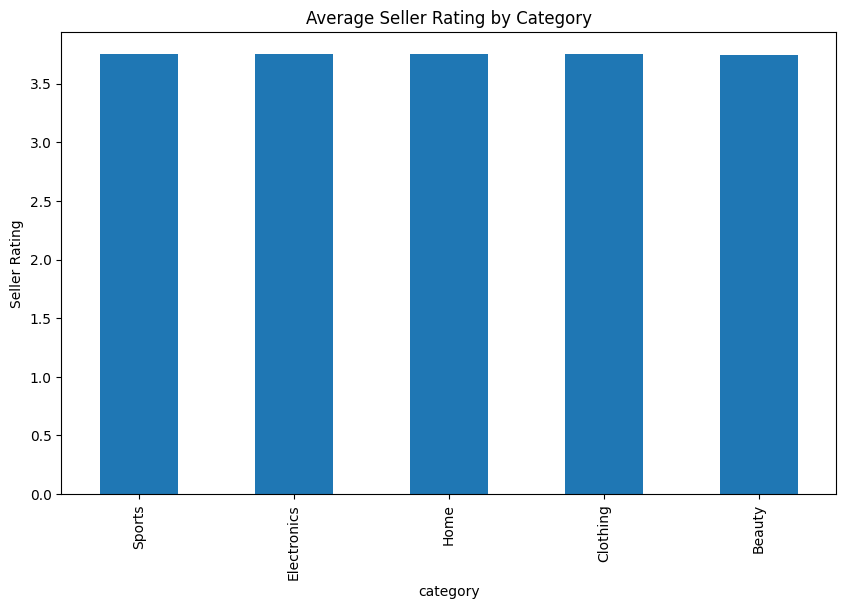

In [27]:
plt.figure(figsize=(10,6))

seller_performance.plot(kind='bar')

plt.title('Average Seller Rating by Category')
plt.ylabel('Seller Rating')

plt.show()

## Business Interpretation

Seller performance directly affects:
- customer experience
- delivery reliability
- product quality consistency

Monitoring seller ratings helps identify:
- operational risks
- supplier quality issues
- fulfillment reliability concerns

## KPI 7- Customer Satisfaction KPI

Overall Customer Ratings is 3.93 signaling fairly satisfied customers

In [41]:
overall_customer_ratings = (
    df['rating']
    .mean()
)

print(f"Overall Customer Rate: {overall_customer_ratings:.2f}%")

Overall Customer Rate: 3.93%


In [33]:
customer_ratings = (
    df.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
)

customer_ratings

category
Electronics    4.206092
Home           3.902324
Sports         3.876259
Clothing       3.826767
Beauty         3.824287
Name: rating, dtype: float64

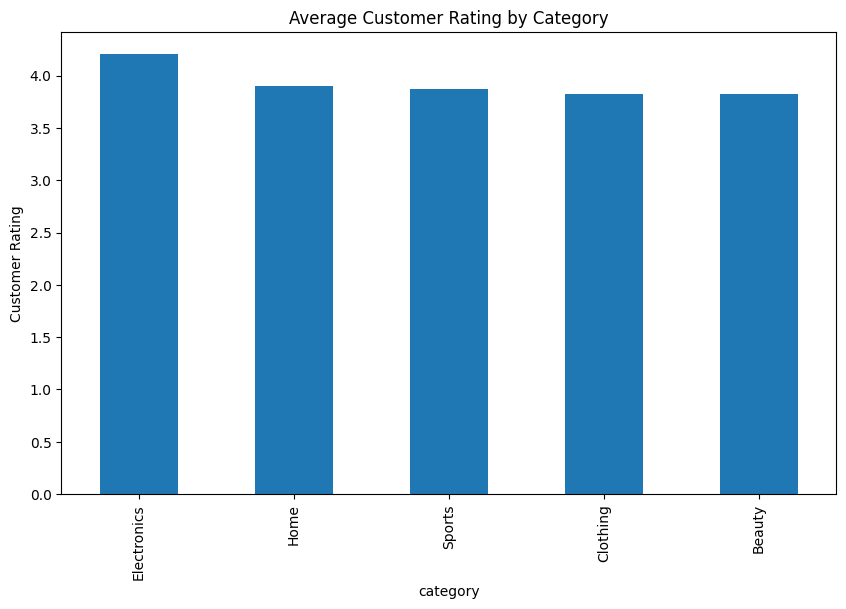

In [34]:
plt.figure(figsize=(10,6))

customer_ratings.plot(kind='bar')

plt.title('Average Customer Rating by Category')
plt.ylabel('Customer Rating')

plt.show()

##### The above chart indicates good customer satisfaction rate by Amazon on an overall level, with the Electronics category returning the highest pleased customer rate(4.20), followed by the Home Category(3.90)

KPI Summary Table

In [43]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Fill Rate',
        'Return Rate',
        'Average Shipping Time',
        'Delayed Shipment Rate',
        'overall_customer_ratings'
    ],
    
    'Value': [
        f"{fill_rate:.2f}%",
        f"{return_rate:.2f}%",
        f"{avg_shipping_time:.2f} Days",
        f"{delay_rate:.2f}%",
        f"{overall_customer_ratings:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Fill Rate,58.90%
1,Return Rate,11.60%
2,Average Shipping Time,3.17 Days
3,Delayed Shipment Rate,29.50%
4,overall_customer_ratings,3.93%


# Key Operational Insights

## Findings

- Certain categories demonstrate higher return rates, increasing reverse logistics complexity.
- Shipping performance varies significantly across locations.
- Delayed shipment rates indicate potential transportation inefficiencies.
- Inventory risk analysis suggests exposure to potential stockout situations.

## Recommendations

- Improve inventory allocation for high-demand categories.
- Increase monitoring of high-risk inventory products.
- Optimize transportation operations in high-delay regions.
- Strengthen seller quality management processes.